In [34]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update({
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (4, 3)
double_column = (8, 6)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [35]:
# Load the individual results
visit_fits_files = glob("./FNPCA 5px final/*visit*.h5")
visit_fits = [IndividualFitResults.load(v) for v in visit_fits_files]

visit_fits = sorted(visit_fits, key=lambda x: x.visit_name)

# Load the photometry data
phot_files = glob("./Raw photometry/*.h5")
phot_data = [PhotometryData.load(f) for f in phot_files] 

# Correcting phot data for visit 4 (this is also done by the pipeline before fitting)
cutoff = np.where(phot_data[4].raw_flux < 0.995)[0][0]
phot_data[4].raw_flux[:cutoff] /= np.median(phot_data[4].raw_flux[:cutoff])
phot_data[4].raw_flux[cutoff:] /= np.median(phot_data[4].raw_flux[cutoff:])

2026-05-22 19:42:40,423 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



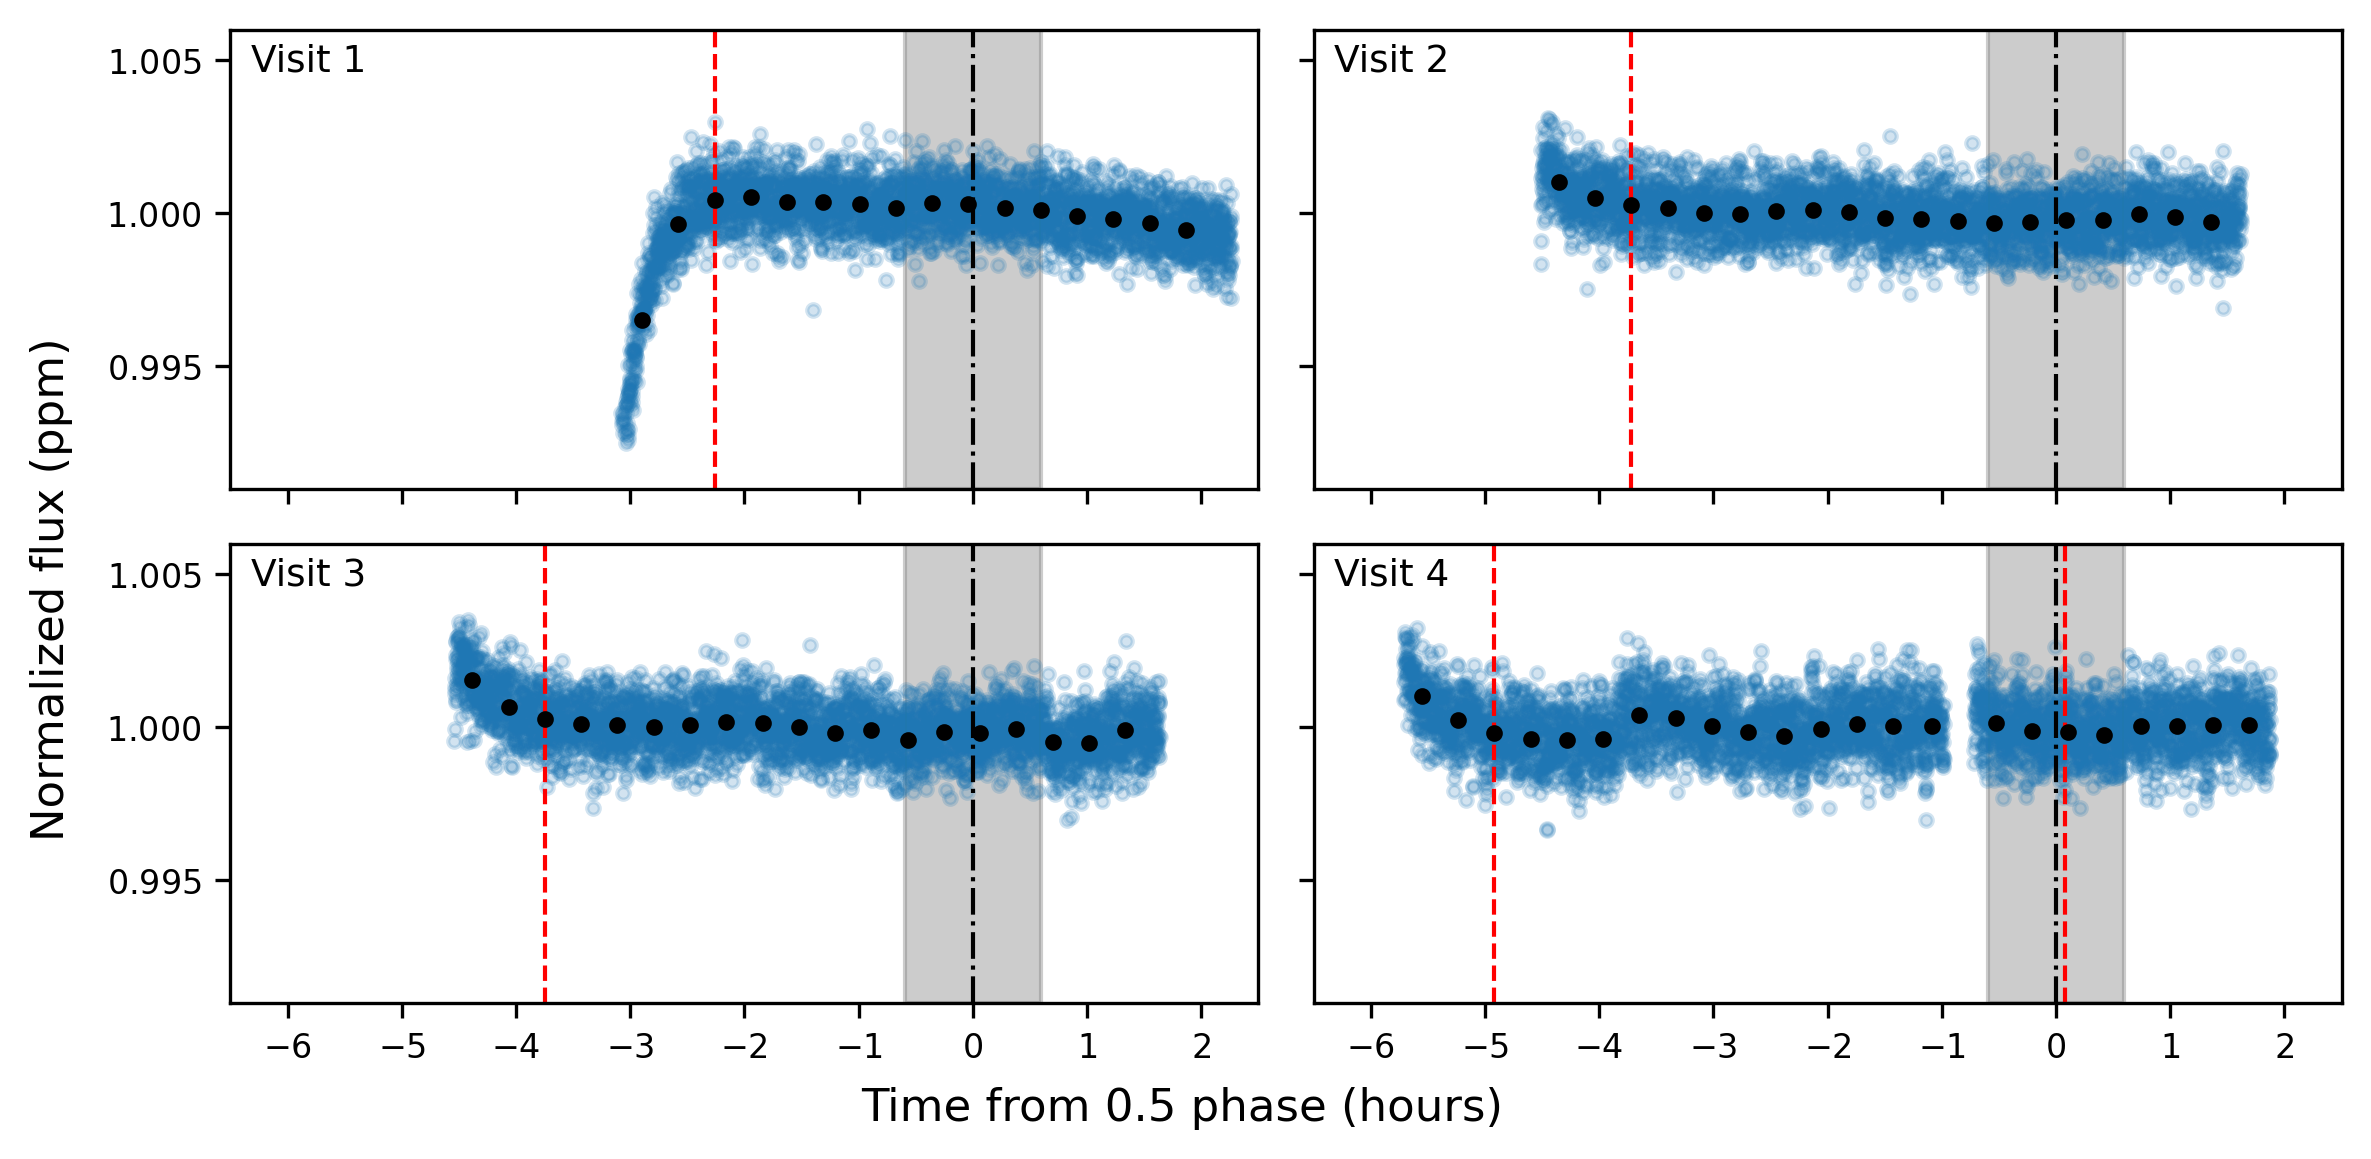

In [36]:
# Plotting the raw photometry
fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharey=True, sharex=True)
fig.subplots_adjust(hspace=0, wspace=0)

duration = get_eclipse_duration_from_res(visit_fits[0]) # hours

def plot_visit(phot, visit, ax, visit_number):
	middle = visit.predicted_t_sec.nominal_value

	x = (phot.time - middle - visit.start_time) * 24 # hours
	y = phot.raw_flux

	bin_size = 200
	x_bin, _ = bin_data(x, bin_size)
	y_bin, _ = bin_data(y, bin_size)
	y_err = visit.results['y_err'].nominal_value / np.sqrt(bin_size)

	ax.plot(x, y, marker='.', linestyle='', alpha=0.2)
	ax.axvline(x[500], linestyle='--', color='red')
	ax.axvline(0, linestyle='-.', color='black')
	ax.axvspan(-duration/2, duration/2, color='grey', alpha=0.4)

	ax.errorbar(x_bin, y_bin, y_err, marker='.', linestyle='', color='black')
	
	if visit_number == 4:
		axs[1,1].axvline(x[cutoff+500], linestyle='--', color='red')

	ax.text(0.02, 0.97, f"Visit {visit_number}", transform=ax.transAxes, verticalalignment='top', horizontalalignment='left')

plot_visit(phot_data[0], visit_fits[0], axs[0, 0], 1)
plot_visit(phot_data[1], visit_fits[1], axs[0, 1], 2)
plot_visit(phot_data[2], visit_fits[2], axs[1, 0], 3)
plot_visit(phot_data[4], visit_fits[3], axs[1, 1], 4)

#axs[0,0].set_yticks([0.9925, 0.9950, 0.9975, 1, 1.0025])
axs[0,0].set_xlim([-6.5, 2.5])
axs[0,0].set_ylim([0.991, 1.006])

fig.supylabel("Normalized flux (ppm)", x=0.02)

fig.supxlabel("Time from 0.5 phase (hours)", y=0.05)

fig.tight_layout()

plt.savefig("figures/gj_raw_flux.pdf", bbox_inches='tight')
plt.savefig("figures/gj_raw_flux.png", bbox_inches='tight')

Settled at index 1410 time 2.27+/-0.04 hrs
Settled at index 459 time 0.729+/-0.014 hrs
Settled at index 433 time 0.687+/-0.016 hrs
Settled at index 383 time 0.608+/-0.016 hrs
Settled at index 308 time 0.489+/-0.028 hrs


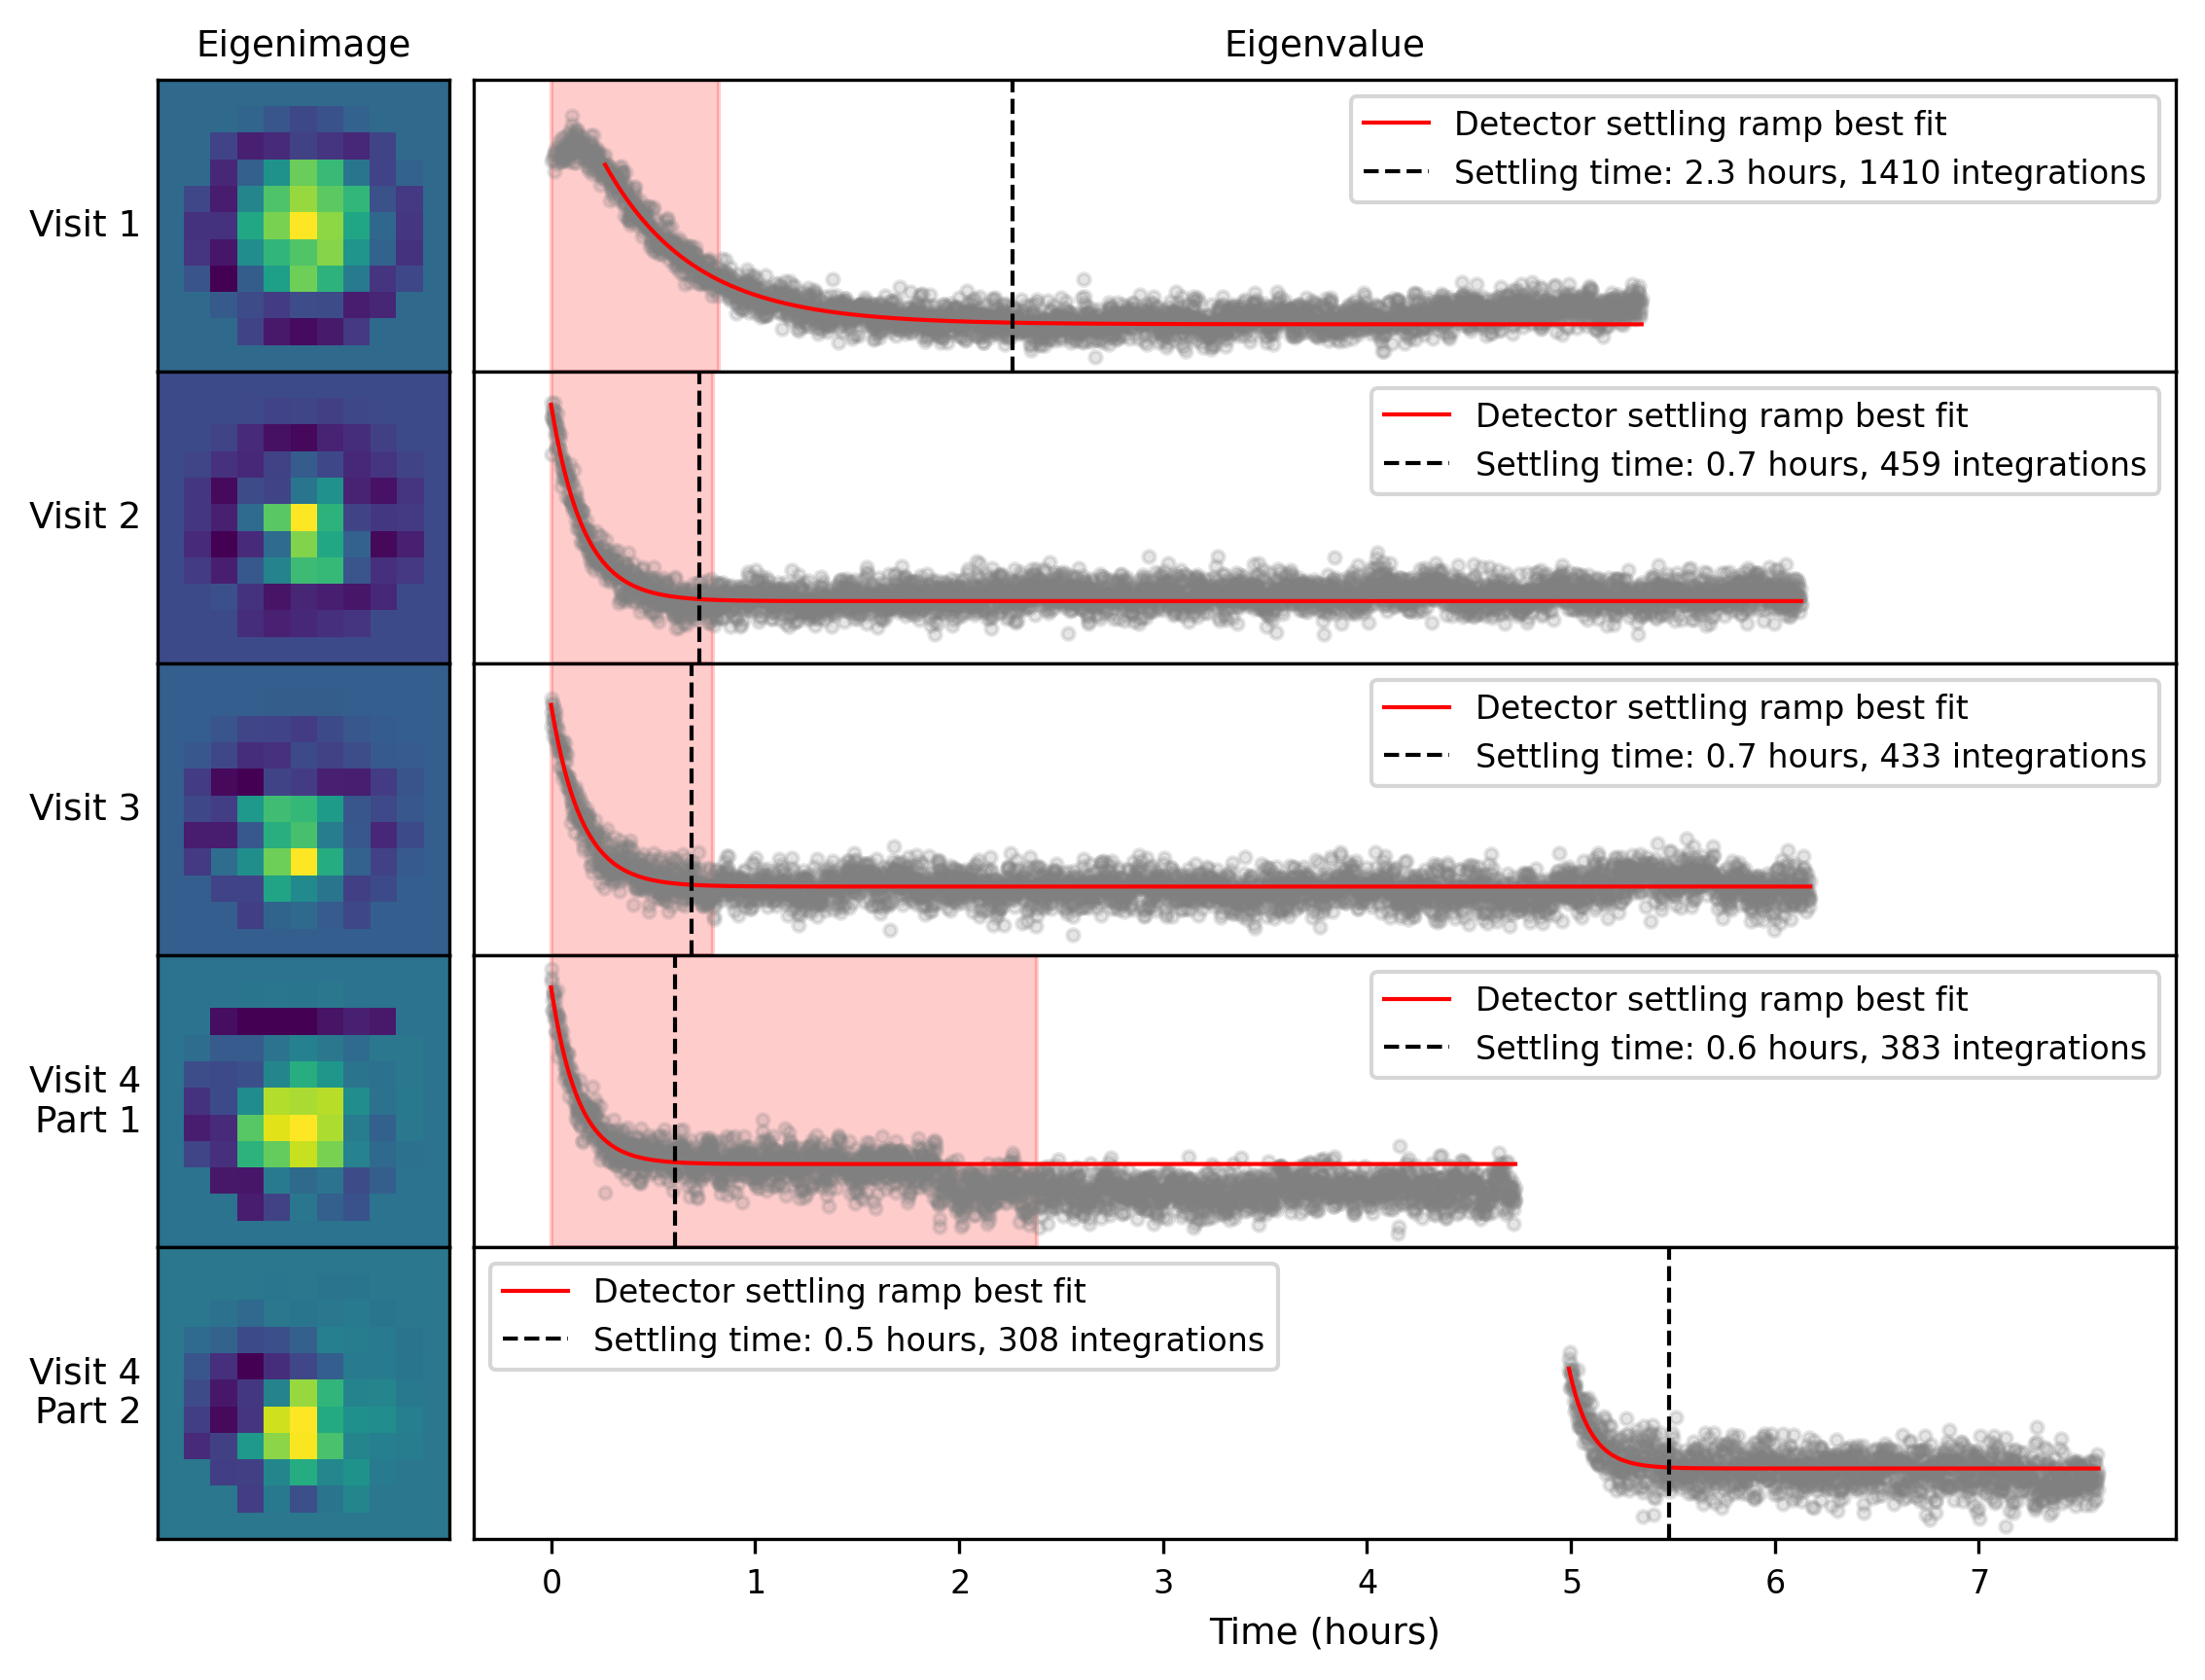

In [37]:
def ramp(x, a, b, c):
	return a * (1 - np.exp(-b * x)) + c

fig, axs = plt.subplots(5, 2, figsize=(7,5), sharex='col', sharey='col', width_ratios=[1,5])

inds = [0, 1, 1, 1, 1]
names = ["Visit 1", "Visit 2", "Visit 3", "Visit 4\nPart 1", "Visit 4\nPart 2"]

taus = []

for i in range(5):
	frames = phot_data[i].normalized_frames
	time = phot_data[i].time
	x = (time - np.min(time)) * 24
	if i == 3:
		frames = phot_data[3].normalized_frames[:cutoff]
		time = phot_data[3].time[:cutoff]
		x = (time - np.min(time)) * 24
	elif i == 4:
		frames = phot_data[3].normalized_frames[cutoff:]
		start = np.min(time)
		time = phot_data[3].time[cutoff:]
		x = (time - start) * 24

	eigenvalues, eigenvectors, _ = perform_fn_pca_on_aperture(frames)	

	y = eigenvalues[inds[i]]
	
	axs[i, 0].imshow(eigenvectors[inds[i]])
	axs[i, 1].plot(x, y, marker='.', linestyle='', color='grey', alpha=0.2)
	axs[i, 1].set_yticks([])
	axs[i, 0].set_yticks([])
	axs[i, 0].set_xticks([])
	axs[i, 0].set_ylabel(names[i], rotation=0, ha='right', va='center')

	x_model = np.array(x)
	y_model = np.array(y)
	if i == 0:
		x_model = np.array(x[150:])
		y_model = np.array(y[150:])
	x_model_offset = np.min(x_model)
	x_model -= x_model_offset

	params, cov = curve_fit(ramp, x_model[:1000], y_model[:1000], p0=[1, 1, 0])

	axs[i, 1].plot(x_model + x_model_offset, ramp(x_model, *params), color='red', label='Detector settling ramp best fit')

	param_err = np.sqrt(np.diag(cov))
	
	settled_time = (np.log(100) / ufloat(params[1], param_err[1]) + x_model_offset)
	taus.append(settled_time - np.min(x))
	settled_index = np.argmin(np.abs(x - settled_time.nominal_value))
	axs[i, 1].axvline(x[settled_index], linestyle='--', color='black', label=f'Settling time: {(settled_time.nominal_value- np.min(x)):0.1f} hours, {settled_index} integrations')

	axs[i, 1].legend()

	if i != 4:
		cut = 500 if i != 3 else 1500
		axs[i, 1].axvspan(x[0], x[cut], color='red', alpha=0.2)
	
	print(f"Settled at index {settled_index} time {settled_time - np.min(x)} hrs")


axs[-1, 1].set_xlabel("Time (hours)")
axs[0, 0].set_title("Eigenimage")
axs[0, 1].set_title("Eigenvalue")

plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)

plt.savefig("figures/settling_pca.pdf", bbox_inches='tight')
plt.savefig("figures/settling_pca.png", bbox_inches='tight')
	

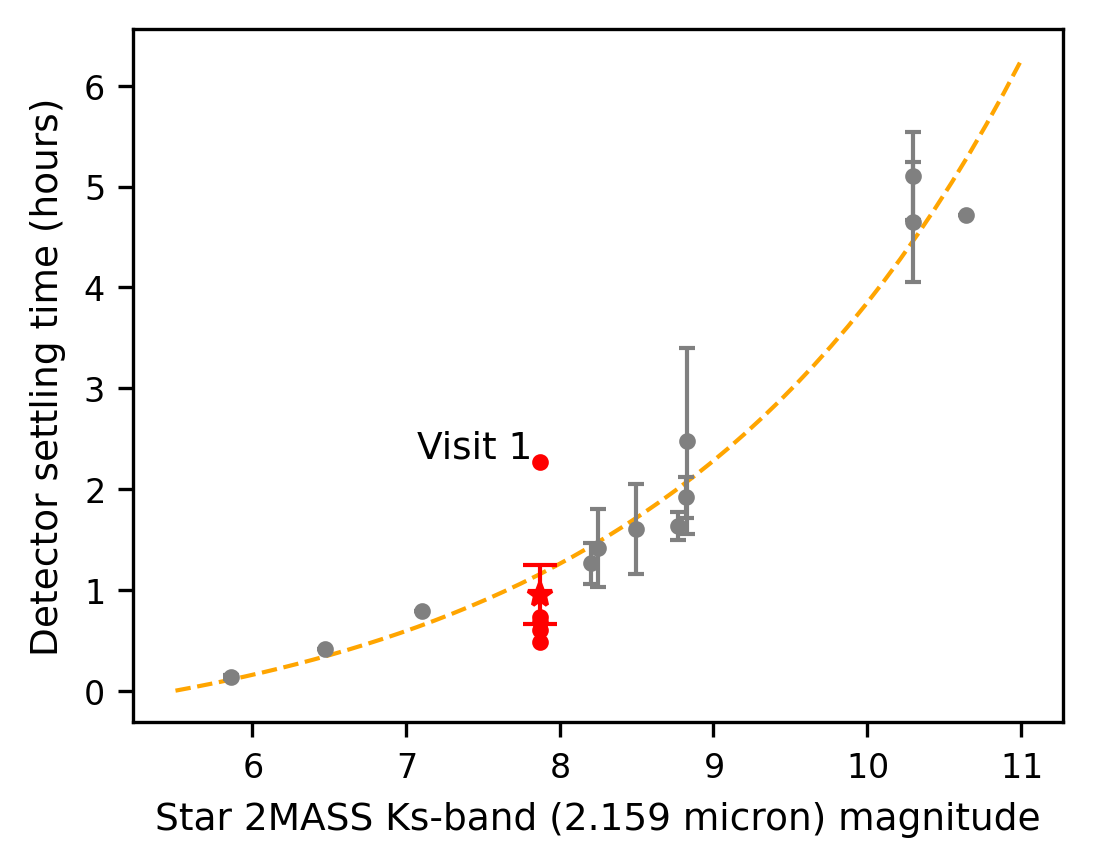

In [38]:
# Plotting detector settling time

settling_times = np.loadtxt("../connors_et_al_2025/settling_times.csv", delimiter=',')

plt.figure(figsize=single_column)

ks_mag = 7.869

mag_model = np.linspace(5.5, 11)
settling_model = 0.063 * np.exp(0.427 * mag_model) - 0.657
plt.plot(mag_model, settling_model, linestyle='--', color='orange')

visit1_tau = taus[0]
visit2_tau = taus[1]
visit3_tau = taus[2]
visit4_tau = taus[3]
visit5_tau = taus[4]

plt.errorbar([ks_mag], [visit1_tau.nominal_value], [visit1_tau.std_dev], marker='.', linestyle='', color='red', alpha=1)
plt.errorbar([ks_mag], [visit2_tau.nominal_value], [visit2_tau.std_dev], marker='.', linestyle='', color='red', alpha=1)
plt.errorbar([ks_mag], [visit3_tau.nominal_value], [visit3_tau.std_dev], marker='.', linestyle='', color='red', alpha=1)
plt.errorbar([ks_mag], [visit4_tau.nominal_value], [visit4_tau.std_dev], marker='.', linestyle='', color='red', alpha=1)
plt.errorbar([ks_mag], [visit5_tau.nominal_value], [visit5_tau.std_dev], marker='.', linestyle='', color='red', alpha=1)

plt.annotate("Visit 1", (ks_mag - 0.05, visit1_tau.nominal_value + 0.05), ha='right')

taus_nominal_value = [t.nominal_value for t in taus]
tau_combined = np.mean(taus_nominal_value)
tau_combined_err = np.std(taus_nominal_value) / np.sqrt(len(taus))

plt.errorbar([ks_mag], [tau_combined], [tau_combined_err], marker='*', linestyle='', color='red', capsize=4)

plt.errorbar(settling_times[2], settling_times[0], settling_times[1], marker='.', linestyle='', color='grey', capsize=2)
plt.xlabel("Star 2MASS Ks-band (2.159 micron) magnitude")
plt.ylabel("Detector settling time (hours)")
plt.savefig("figures/gj3929b_settling.pdf", bbox_inches='tight')
plt.savefig("figures/gj3929b_settling.png", bbox_inches='tight')
plt.show()

1.35+/-0.04
-0.215+/-0.030
-0.284+/-0.031
-0.384+/-0.030


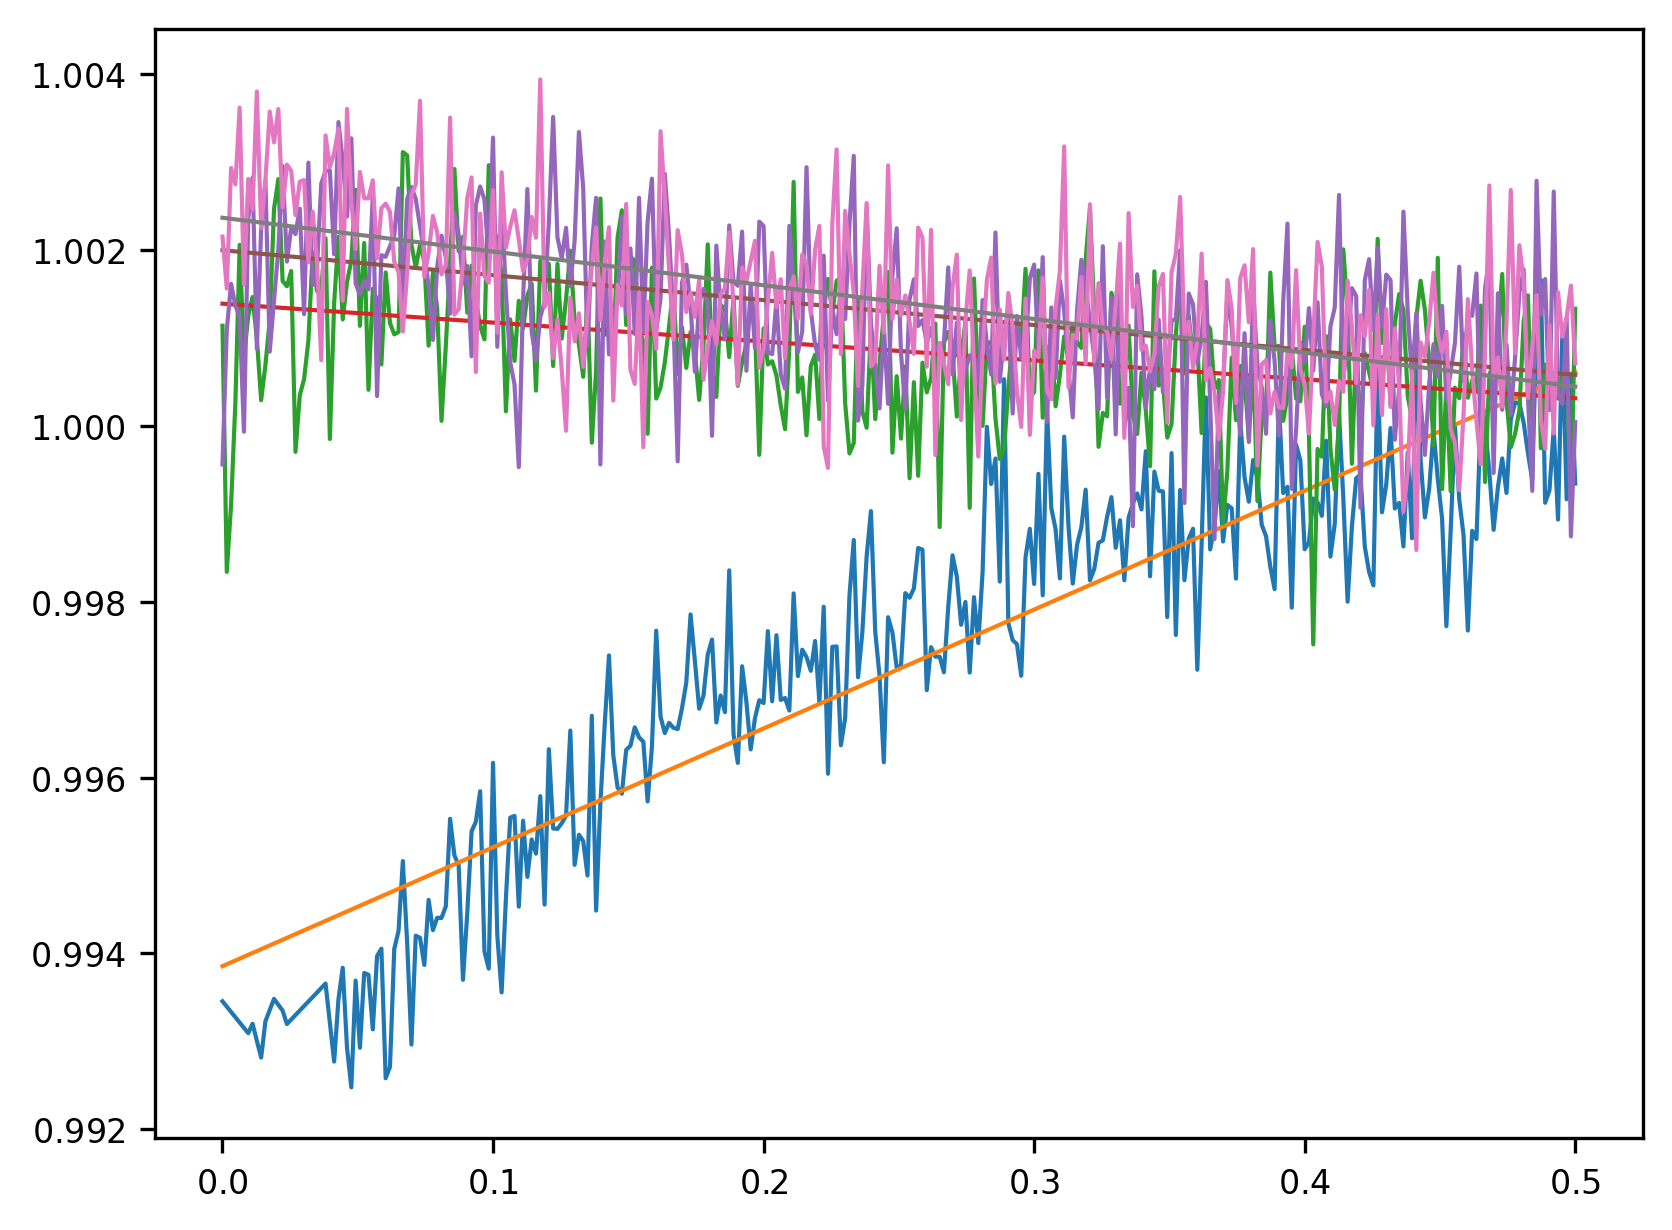

In [39]:
from uncertainties import ufloat
from scipy.optimize import curve_fit

def linear(x, m, b):
	return m * x + b

def fit_slope(data):
	y = data.raw_flux
	x = (data.time - np.min(data.time)) * 24
	
	inds = np.where(x < 0.5)

	popt, pcov = curve_fit(linear, x[inds], y[inds])

	m, b = popt
	m_err = np.sqrt(pcov[0, 0])

	m, b = np.polyfit(x[inds], y[inds], 1)
	y_model = m * x[inds] + b
	
	plt.plot(x[inds], y[inds])
	plt.plot(x[inds], y_model)

	diff = ufloat(m, m_err) * 1e2 # Change in ppm over 0.5 min
	print(diff)

fit_slope(phot_data[0])
fit_slope(phot_data[1])
fit_slope(phot_data[2])
fit_slope(phot_data[3])